In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [11]:
# Read the CSV file
df = pd.read_csv('scheduling_data.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# Clean and prepare the data
print("\nCleaning data...")

Data loaded successfully!
Shape: (87, 16)

First few rows:
  Scheduling Algorithm     Type  Process ID  Arrival Time  Burst Time  \
0         ContextAware  Process         7.0          47.0        55.0   
1         ContextAware  Process         6.0          99.0        39.0   
2         ContextAware  Process         1.0          24.0        58.0   
3         ContextAware  Process         4.0          74.0        35.0   
4         ContextAware  Process         8.0          85.0        39.0   

   Start Time  Completion Time  Waiting Time  Turnaround Time Assigned Nodes  \
0      47.000         102.0000        0.0000          55.0000            "2"   
1     102.000         141.0000        3.0000          42.0000            "2"   
2      24.000         176.4950        0.0000         152.4950          "2;3"   
3      74.000          98.8917        0.0000          24.8917          "1;3"   
4     176.495         215.4950       91.4946         130.4950            "2"   

      Status Metric V

In [12]:
# Remove extra quotes from Assigned Nodes column
df['Assigned Nodes'] = df['Assigned Nodes'].astype(str).str.replace('"', '')

# Extract summary data for each algorithm
algorithms = df['Scheduling Algorithm'].unique()
print(f"Algorithms found: {algorithms}")

# Create summary statistics dataframe
summary_stats = []


Algorithms found: ['ContextAware' 'FCFS' 'SJF']


In [13]:
for algo in algorithms:
    algo_data = df[df['Scheduling Algorithm'] == algo]
    summary_data = algo_data[algo_data['Type'] == 'Summary']
    
    if not summary_data.empty:
        stats = {}
        stats['Algorithm'] = algo
        
        # Extract metrics from summary rows
        for _, row in summary_data.iterrows():
            if pd.notna(row['Metric']) and pd.notna(row['Value']):
                metric = row['Metric']
                value = row['Value']
                
                # Convert string values to numeric where possible
                if isinstance(value, str):
                    if 'calculations' in value:
                        value = float(value.split()[0])
                    else:
                        try:
                            value = float(value)
                        except:
                            pass
                
                stats[metric] = value
        
        summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)
print("\nSummary statistics extracted:")
print(summary_df)


Summary statistics extracted:
       Algorithm Metric  Total Processes  Scheduled Processes  \
0  Context-Aware  Value              8.0                  8.0   
1           FCFS  Value              8.0                  8.0   
2            SJF  Value              8.0                  8.0   

   Failed Processes  Success Rate  Total Execution Time  Average Waiting Time  \
0               0.0         100.0               215.495               34.7606   
1               0.0         100.0               202.000               36.8750   
2               0.0         100.0               376.000              105.5000   

   Average Turnaround Time  Throughput  ...  Bandwidth Utilization  \
0                  86.3963    0.037124  ...                5.04810   
1                  78.2500    0.039604  ...                    NaN   
2                 146.8750    0.021277  ...                2.89319   

   Scheduling Overhead  Process Score Calculations  Node Score Calculations  \
0                 70.0 

In [14]:
# Create comprehensive performance comparison plots
fig = plt.figure(figsize=(20, 24))

<Figure size 2000x2400 with 0 Axes>

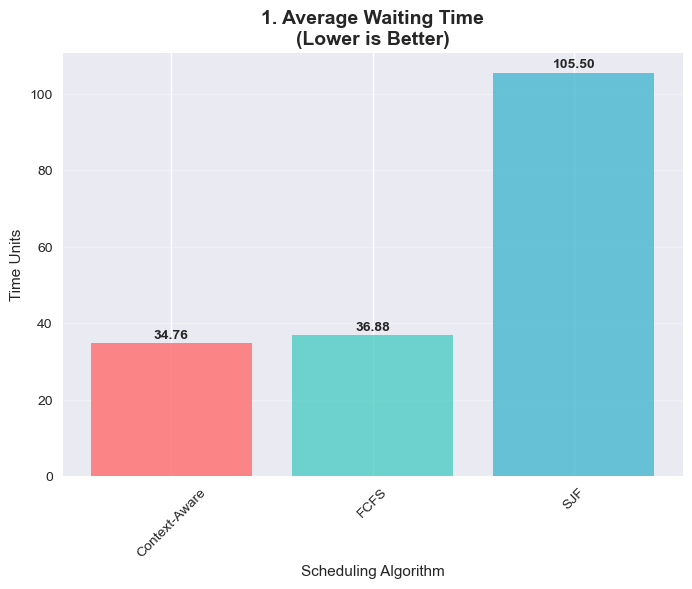

In [23]:
# 1. Average Waiting Time (Lower is Better)
if 'Average Waiting Time' in summary_df.columns:
    bars = plt.bar(summary_df['Algorithm'], summary_df['Average Waiting Time'], 
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
    plt.title('1. Average Waiting Time\n(Lower is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Time Units')
    plt.xlabel('Scheduling Algorithm')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

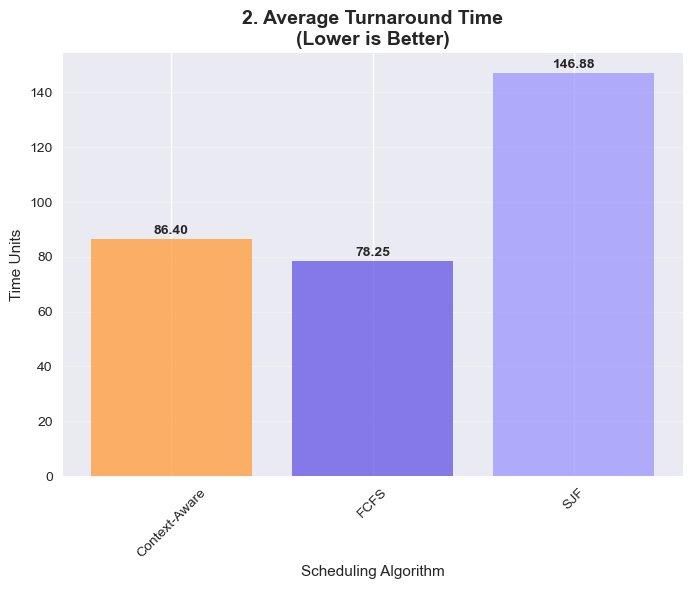

In [24]:
# 2. Average Turnaround Time (Lower is Better)
if 'Average Turnaround Time' in summary_df.columns:
    bars = plt.bar(summary_df['Algorithm'], summary_df['Average Turnaround Time'], 
                   color=['#FF9F43', '#6C5CE7', '#A29BFE'], alpha=0.8)
    plt.title('2. Average Turnaround Time\n(Lower is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Time Units')
    plt.xlabel('Scheduling Algorithm')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

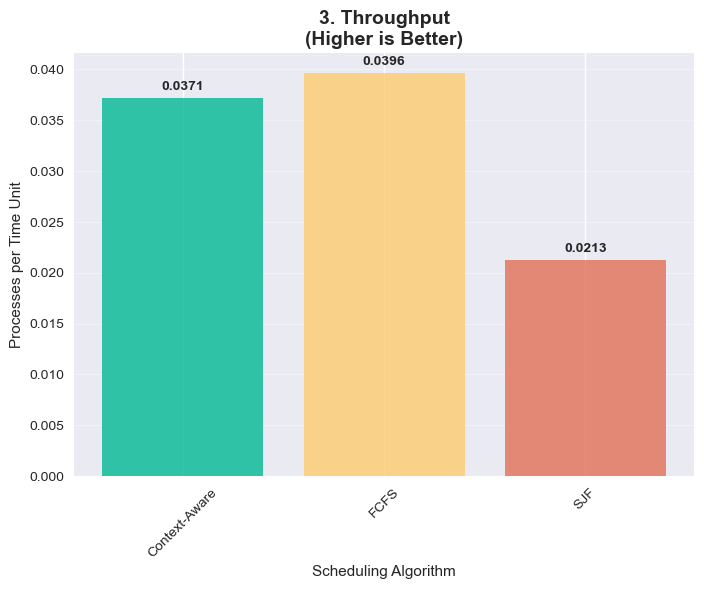

In [25]:
# 3. Throughput (Higher is Better)
if 'Throughput' in summary_df.columns:
    bars = plt.bar(summary_df['Algorithm'], summary_df['Throughput'], 
                   color=['#00B894', '#FDCB6E', '#E17055'], alpha=0.8)
    plt.title('3. Throughput\n(Higher is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Processes per Time Unit')
    plt.xlabel('Scheduling Algorithm')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
                f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

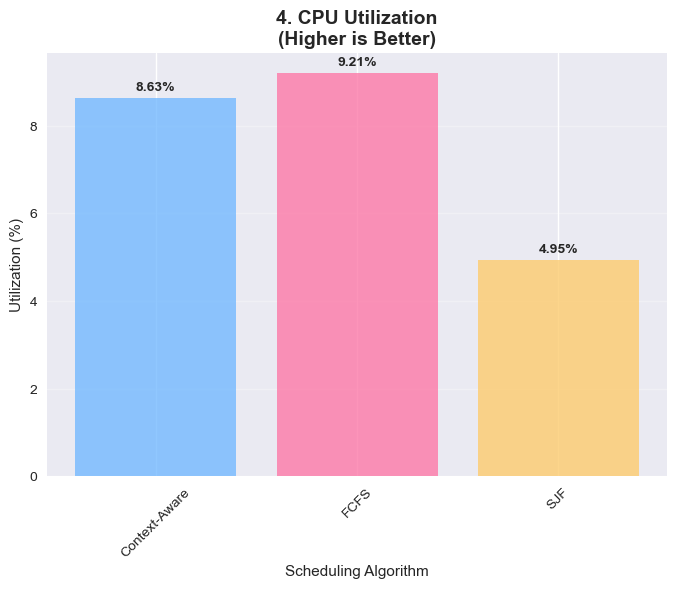

In [26]:
# 4. CPU Utilization (Higher is Better)
if 'CPU Utilization' in summary_df.columns:
    bars = plt.bar(summary_df['Algorithm'], summary_df['CPU Utilization'], 
                   color=['#74B9FF', '#FD79A8', '#FDCB6E'], alpha=0.8)
    plt.title('4. CPU Utilization\n(Higher is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Utilization (%)')
    plt.xlabel('Scheduling Algorithm')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

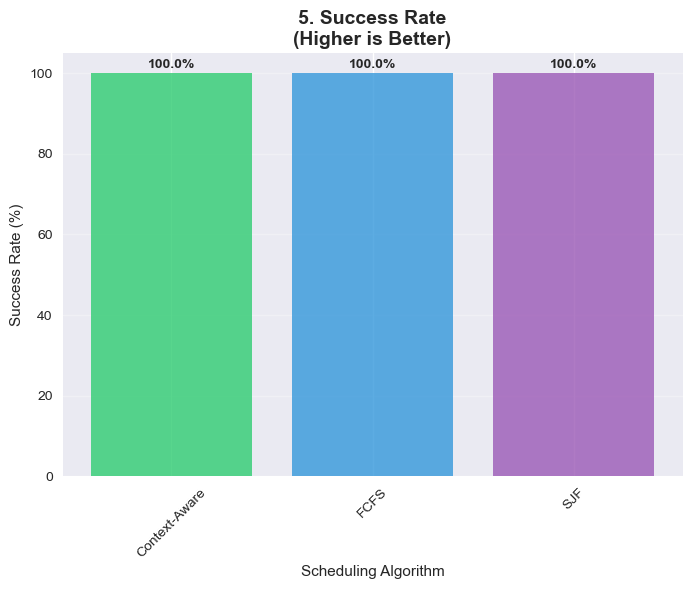

In [22]:
# 5. Success Rate (Higher is Better)
if 'Success Rate' in summary_df.columns:
    bars = plt.bar(summary_df['Algorithm'], summary_df['Success Rate'], 
                   color=['#2ECC71', '#3498DB', '#9B59B6'], alpha=0.8)
    plt.title('5. Success Rate\n(Higher is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Success Rate (%)')
    plt.xlabel('Scheduling Algorithm')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)


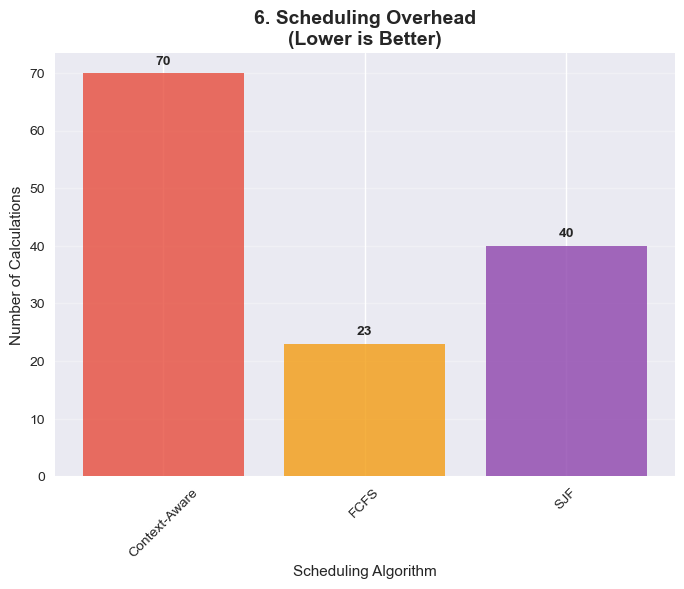

In [21]:
# 6. Scheduling Overhead (Lower is Better)
if 'Scheduling Overhead' in summary_df.columns:
    bars = plt.bar(summary_df['Algorithm'], summary_df['Scheduling Overhead'], 
                   color=['#E74C3C', '#F39C12', '#8E44AD'], alpha=0.8)
    plt.title('6. Scheduling Overhead\n(Lower is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Calculations')
    plt.xlabel('Scheduling Algorithm')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)

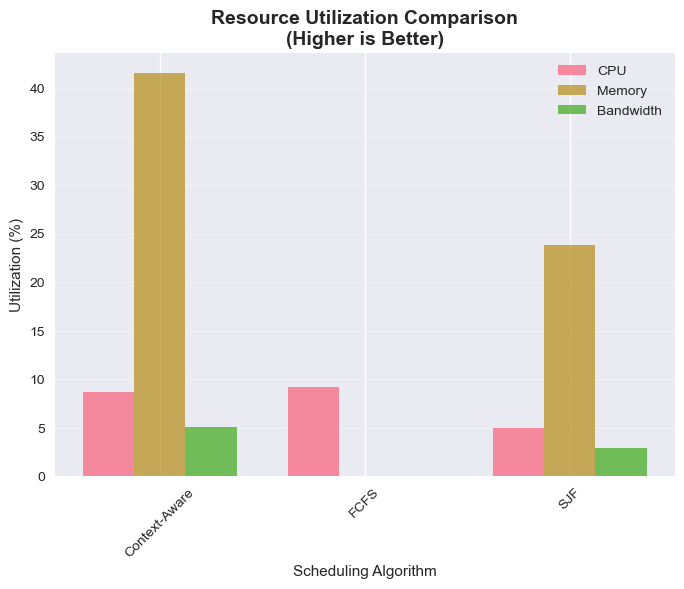

In [27]:
# 7. Resource Utilization Comparison (Combined)
utilization_metrics = []
for metric in ['CPU Utilization', 'Memory Utilization', 'Bandwidth Utilization']:
    if metric in summary_df.columns:
        utilization_metrics.append(metric)

if utilization_metrics:
    x = np.arange(len(summary_df['Algorithm']))
    width = 0.25
    
    for i, metric in enumerate(utilization_metrics):
        values = summary_df[metric] if metric in summary_df.columns else [0] * len(summary_df)
        plt.bar(x + i*width, values, width, label=metric.replace(' Utilization', ''), alpha=0.8)
    
    plt.title('Resource Utilization Comparison\n(Higher is Better)', fontsize=14, fontweight='bold')
    plt.ylabel('Utilization (%)')
    plt.xlabel('Scheduling Algorithm')
    plt.xticks(x + width, summary_df['Algorithm'], rotation=45)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

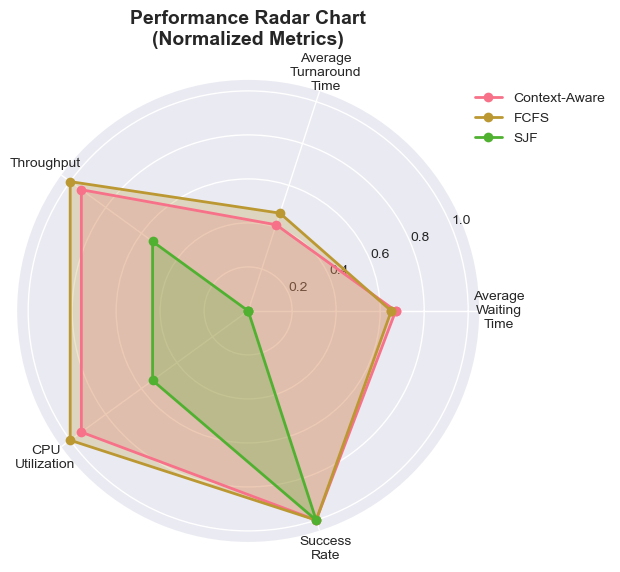

In [31]:
# 8. Performance Radar Chart
from math import pi

# Normalize metrics for radar chart (0-1 scale)
radar_metrics = ['Average Waiting Time', 'Average Turnaround Time', 'Throughput', 
                'CPU Utilization', 'Success Rate']
available_metrics = [m for m in radar_metrics if m in summary_df.columns]

if len(available_metrics) >= 3:
    N = len(available_metrics)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 6))
    
    for idx, algo in enumerate(summary_df['Algorithm']):
        values = []
        for metric in available_metrics:
            val = summary_df[summary_df['Algorithm'] == algo][metric].iloc[0]
            # Normalize different metrics (inverse for waiting/turnaround time)
            if 'Time' in metric:
                normalized_val = 1 - (val / summary_df[metric].max())
            else:
                normalized_val = val / summary_df[metric].max()
            values.append(normalized_val)
        
        values += values[:1]  # Complete the circle
        ax.plot(angles, values, 'o-', linewidth=2, label=algo)
        ax.fill(angles, values, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.replace(' ', '\n') for m in available_metrics])
    plt.title('Performance Radar Chart\n(Normalized Metrics)', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))


Text(0.5, 0.98, 'Fog Computing Scheduler Performance Comparison')

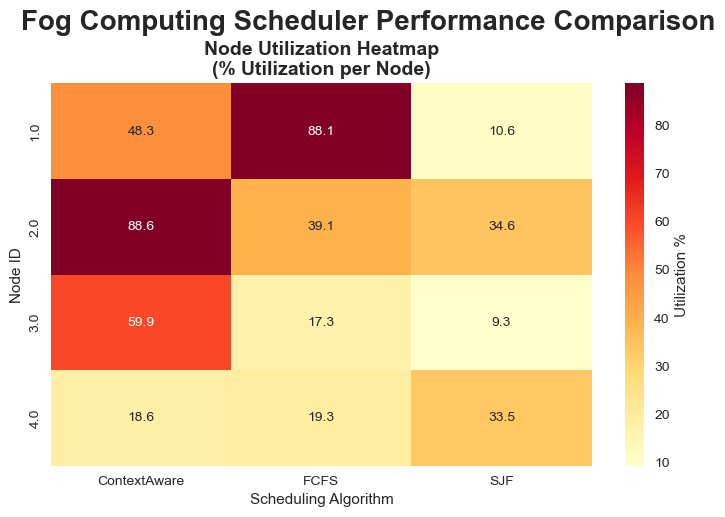

In [32]:
# 9. Node Utilization Analysis
node_data = df[df['Type'] == 'Node Utilization'].copy()
if not node_data.empty:
    # Pivot the data for better visualization
    node_pivot = node_data.pivot_table(
        index='Node ID', 
        columns='Scheduling Algorithm', 
        values='Utilization Percent', 
        aggfunc='first'
    )
    
    # Create heatmap
    sns.heatmap(node_pivot, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Utilization %'})
    plt.title('Node Utilization Heatmap\n(% Utilization per Node)', fontsize=14, fontweight='bold')
    plt.xlabel('Scheduling Algorithm')
    plt.ylabel('Node ID')

plt.tight_layout(pad=3.0)
plt.suptitle('Fog Computing Scheduler Performance Comparison', 
             fontsize=20, fontweight='bold', y=0.98)

In [33]:
# Create detailed summary table
print("\n" + "="*80)
print("DETAILED PERFORMANCE COMPARISON TABLE")
print("="*80)

# Create a formatted summary table
comparison_table = summary_df.copy()

# Select key metrics for comparison
key_metrics = ['Algorithm', 'Average Waiting Time', 'Average Turnaround Time', 
               'Throughput', 'CPU Utilization', 'Success Rate', 'Scheduling Overhead']

available_key_metrics = [m for m in key_metrics if m in comparison_table.columns]
comparison_display = comparison_table[available_key_metrics]

print(comparison_display.to_string(index=False, float_format='%.3f'))

# Performance ranking analysis
print("\n" + "="*80)
print("PERFORMANCE RANKING ANALYSIS")
print("="*80)

rankings = {}
for algo in summary_df['Algorithm']:
    rankings[algo] = {'scores': [], 'total_score': 0}

# Calculate scores for each metric (lower is better for some, higher for others)
metrics_info = {
    'Average Waiting Time': {'direction': 'lower', 'weight': 1},
    'Average Turnaround Time': {'direction': 'lower', 'weight': 1},
    'Throughput': {'direction': 'higher', 'weight': 1},
    'CPU Utilization': {'direction': 'higher', 'weight': 1},
    'Success Rate': {'direction': 'higher', 'weight': 1},
    'Scheduling Overhead': {'direction': 'lower', 'weight': 0.5}
}

for metric, info in metrics_info.items():
    if metric in summary_df.columns:
        values = summary_df[metric].values
        if info['direction'] == 'lower':
            # For metrics where lower is better, inverse ranking
            scores = (max(values) - values) / (max(values) - min(values)) if max(values) != min(values) else [1]*len(values)
        else:
            # For metrics where higher is better, direct ranking
            scores = (values - min(values)) / (max(values) - min(values)) if max(values) != min(values) else [1]*len(values)
        
        for i, algo in enumerate(summary_df['Algorithm']):
            rankings[algo]['scores'].append(scores[i] * info['weight'])
            rankings[algo]['total_score'] += scores[i] * info['weight']

# Sort algorithms by total score
sorted_rankings = sorted(rankings.items(), key=lambda x: x[1]['total_score'], reverse=True)

print("Ranking (Higher score is better):")
for i, (algo, data) in enumerate(sorted_rankings, 1):
    print(f"{i}. {algo}: {data['total_score']:.3f}")

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Find best and worst performers for each metric
insights = []
for metric, info in metrics_info.items():
    if metric in summary_df.columns:
        if info['direction'] == 'lower':
            best_idx = summary_df[metric].idxmin()
            worst_idx = summary_df[metric].idxmax()
            best_algo = summary_df.loc[best_idx, 'Algorithm']
            worst_algo = summary_df.loc[worst_idx, 'Algorithm']
            best_val = summary_df.loc[best_idx, metric]
            worst_val = summary_df.loc[worst_idx, metric]
            insights.append(f"• {metric}: Best = {best_algo} ({best_val:.3f}), Worst = {worst_algo} ({worst_val:.3f})")
        else:
            best_idx = summary_df[metric].idxmax()
            worst_idx = summary_df[metric].idxmin()
            best_algo = summary_df.loc[best_idx, 'Algorithm']
            worst_algo = summary_df.loc[worst_idx, 'Algorithm']
            best_val = summary_df.loc[best_idx, metric]
            worst_val = summary_df.loc[worst_idx, metric]
            insights.append(f"• {metric}: Best = {best_algo} ({best_val:.3f}), Worst = {worst_algo} ({worst_val:.3f})")

for insight in insights:
    print(insight)

print(f"\nOverall Best Performer: {sorted_rankings[0][0]}")
print(f"Overall Score: {sorted_rankings[0][1]['total_score']:.3f}")


DETAILED PERFORMANCE COMPARISON TABLE
    Algorithm  Average Waiting Time  Average Turnaround Time  Throughput  CPU Utilization  Success Rate  Scheduling Overhead
Context-Aware                34.761                   86.396       0.037            8.630       100.000               70.000
         FCFS                36.875                   78.250       0.040            9.207       100.000               23.000
          SJF               105.500                  146.875       0.021            4.946       100.000               40.000

PERFORMANCE RANKING ANALYSIS
Ranking (Higher score is better):
1. FCFS: 5.470
2. Context-Aware: 4.611
3. SJF: 1.319

KEY INSIGHTS
• Average Waiting Time: Best = Context-Aware (34.761), Worst = SJF (105.500)
• Average Turnaround Time: Best = FCFS (78.250), Worst = SJF (146.875)
• Throughput: Best = FCFS (0.040), Worst = SJF (0.021)
• CPU Utilization: Best = FCFS (9.207), Worst = SJF (4.946)
• Success Rate: Best = Context-Aware (100.000), Worst = Context-Awa

In [35]:
# Save results to files (optional)
# try:
#     comparison_display.to_csv('scheduler_performance_comparison.csv', index=False)
#     print(f"\nResults saved to 'scheduler_performance_comparison.csv'")
# except Exception as e:
#     print(f"Could not save CSV file: {e}")

# print("\nAnalysis Complete!")